In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans 
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 

In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) 


In [65]:

df = pd.read_csv('heart_disease_uci.csv')

columns_list = list(df.columns)
data_info = {"Satır Sayısı": len(df), "Sütun Sayısı": len(columns_list)}
print(f"Veri Seti Bilgisi: {data_info}")

Veri Seti Bilgisi: {'Satır Sayısı': 920, 'Sütun Sayısı': 16}


In [67]:

print(df.head())


ages = df['age'].values
print(f"Ortalama Yaş: {np.mean(ages)}")

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
Ortalama

In [69]:

df_clean = df.drop(columns=['id', 'ca', 'thal', 'slope', 'dataset'])


num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])


cat_cols = ['fbs', 'restecg', 'exang']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


df_encoded = pd.get_dummies(df_clean, columns=['sex', 'cp', 'fbs', 'restecg', 'exang'], drop_first=True)


df_encoded['target'] = (df_encoded['num'] > 0).astype(int)

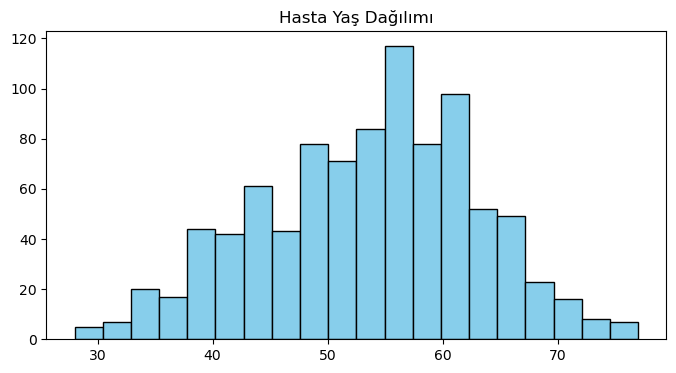

In [71]:

plt.figure(figsize=(8,4))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Hasta Yaş Dağılımı')
plt.show()

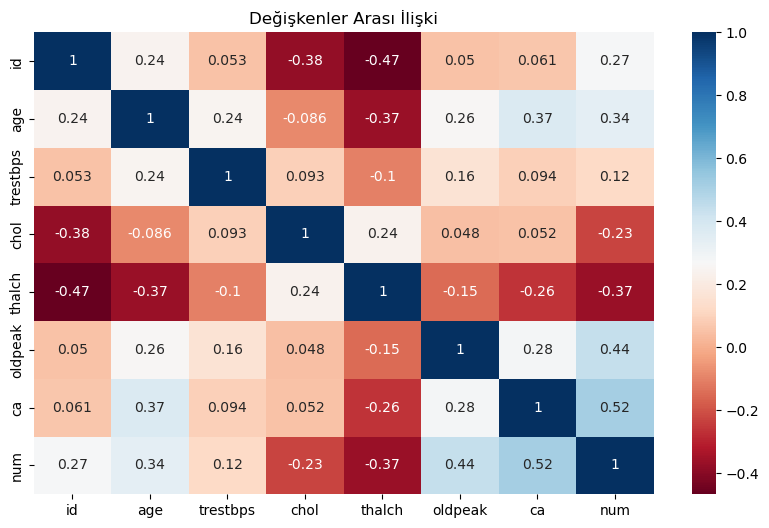

In [73]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.title('Değişkenler Arası İlişki')
plt.show()

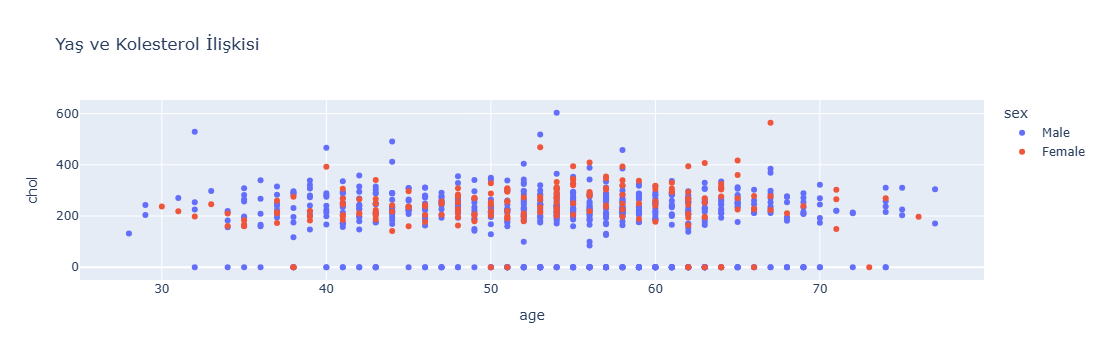

In [75]:
fig = px.scatter(df, x='age', y='chol', color='sex', title='Yaş ve Kolesterol İlişkisi')
fig.show()

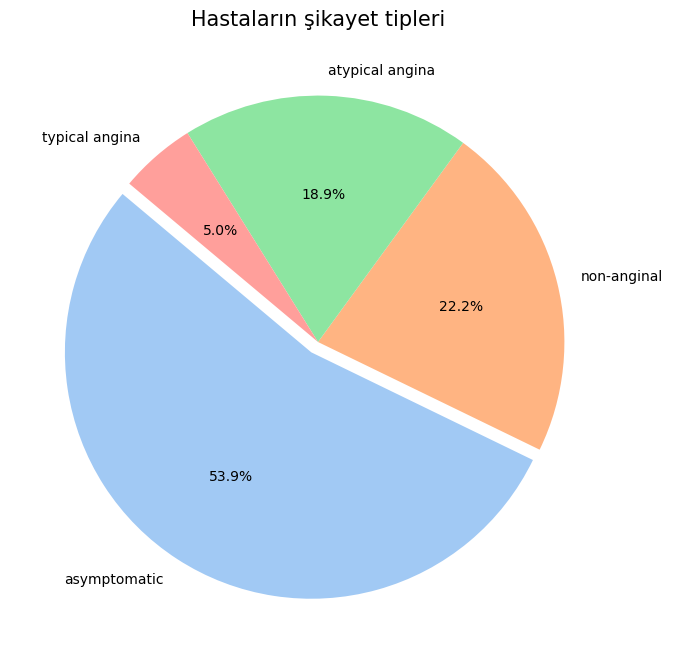

In [77]:
 
plt.figure(figsize=(8, 8))
cp_counts = df['cp'].value_counts()
plt.pie(cp_counts, labels=cp_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05, 0, 0, 0])
plt.title('Hastaların şikayet tipleri', fontsize=15)
plt.show()

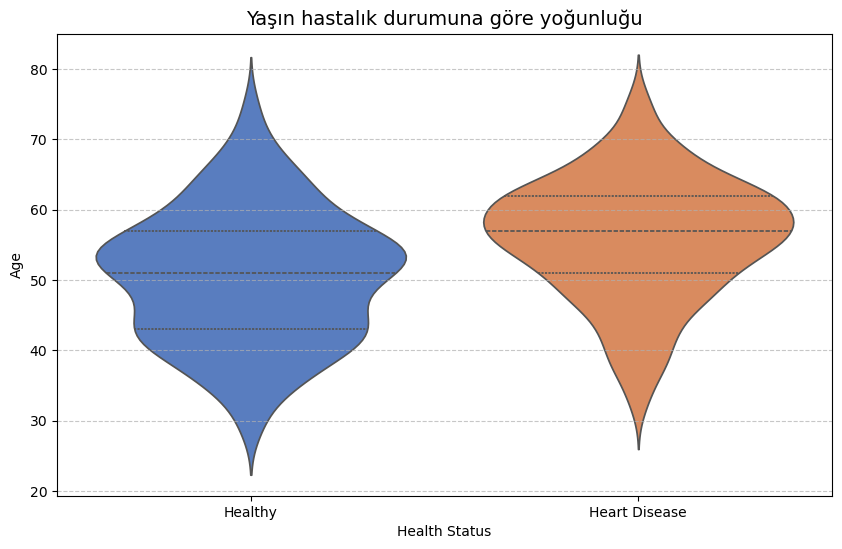

In [79]:

plt.figure(figsize=(10, 6))
df['target_label'] = (df['num'] > 0).map({True: 'Heart Disease', False: 'Healthy'})

sns.violinplot(x='target_label', y='age', data=df, inner="quart", palette="muted")
plt.title('Yaşın hastalık durumuna göre yoğunluğu', fontsize=14)
plt.xlabel('Health Status')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

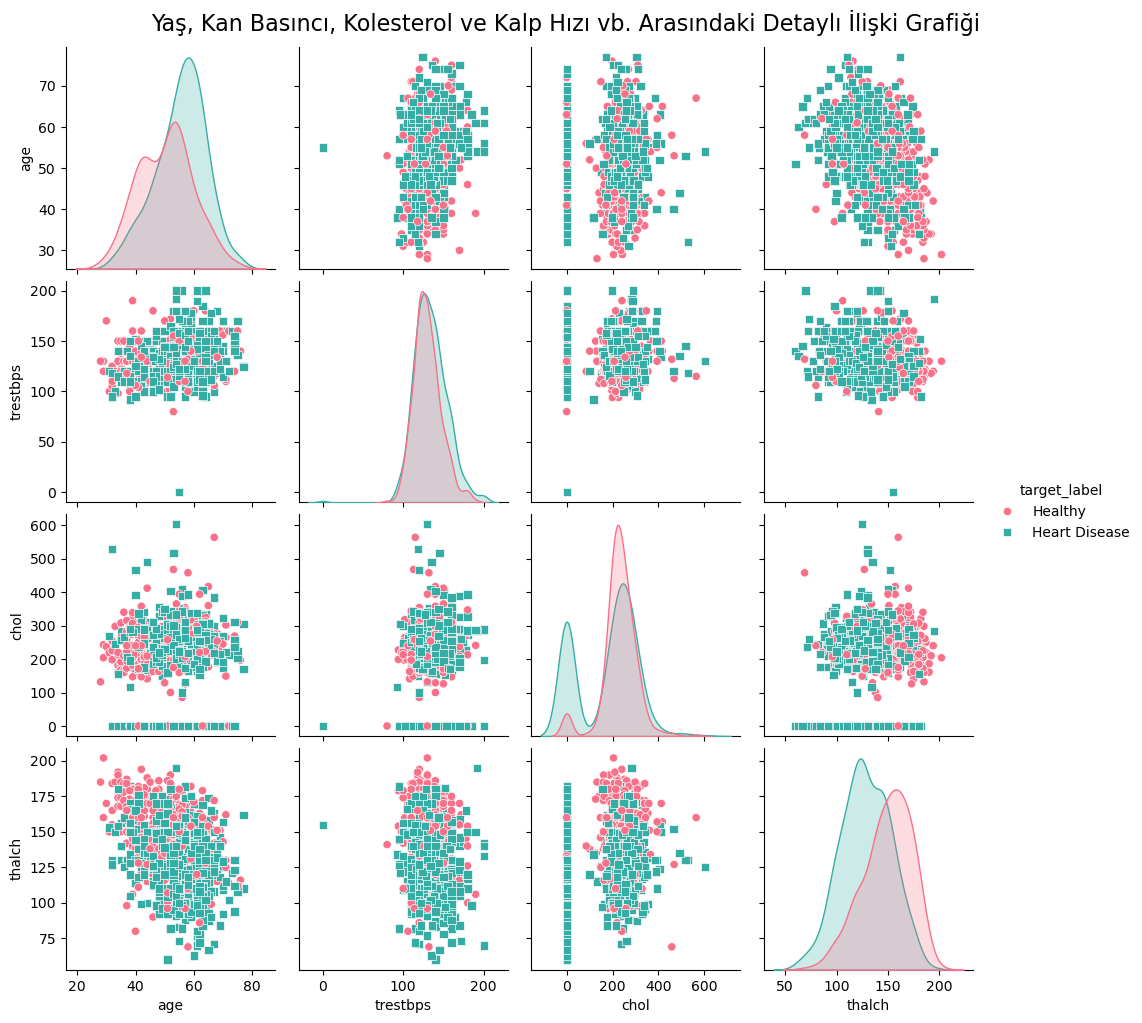

In [81]:

features = ['age', 'trestbps', 'chol', 'thalch', 'target_label']
sns_pair = sns.pairplot(df[features].dropna(), hue='target_label', palette='husl', markers=["o", "s"])
sns_pair.fig.suptitle('Yaş, Kan Basıncı, Kolesterol ve Kalp Hızı vb. Arasındaki Detaylı İlişki Grafiği', y=1.02, fontsize=16)
plt.show()

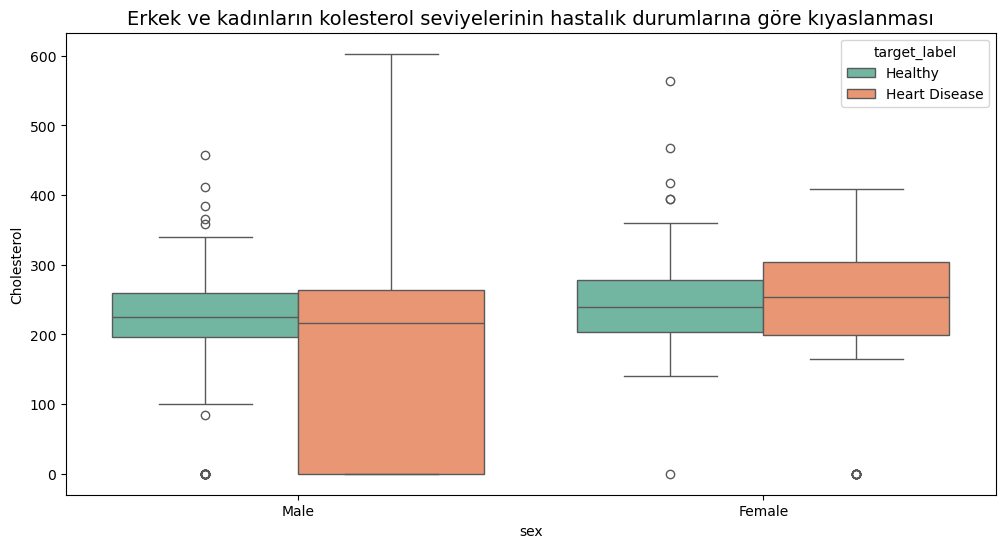

In [83]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='chol', hue='target_label', data=df, palette='Set2')
plt.title('Erkek ve kadınların kolesterol seviyelerinin hastalık durumlarına göre kıyaslanması', fontsize=14)
plt.ylabel('Cholesterol')
plt.show()

In [1]:
fig = px.scatter_3d(df.dropna(), x='age', y='chol', z='thalch', 
                    color='target_label', 
                    title='3D Analiz: Age, Cholesterol, and Max Heart Rate',
                    labels={'thalch': 'Max Heart Rate', 'chol': 'Cholesterol'},
                    opacity=0.7)
fig.show()

NameError: name 'px' is not defined

In [87]:

df['Age_Group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 100], 
                         labels=['Young (<40)', 'Middle (40-50)', 'Adult (50-60)', 'Senior (>60)'])


age_analysis = df.groupby('Age_Group', observed=False)[['trestbps', 'chol', 'thalch']].mean().round(2)

print("--- Yaş Gruplarına Göre Klinik Ortalamalar ---")
display(age_analysis)

--- Yaş Gruplarına Göre Klinik Ortalamalar ---


,trestbps,chol,thalch
Age_Group,,,
Young (<40),124.57,205.86,156.29
Middle (40-50),127.99,216.14,144.96
Adult (50-60),133.54,197.76,134.66
Senior (>60),137.80,181.97,125.64


In [89]:

df['Target_Binary'] = (df['num'] > 0).astype(int)

gender_risk = df.groupby('sex')['Target_Binary'].agg(['count', 'sum', 'mean'])
gender_risk.columns = ['Total Patients', 'Sick Count', 'Risk Ratio (%)']
gender_risk['Risk Ratio (%)'] = (gender_risk['Risk Ratio (%)'] * 100).round(2)

print("--- Cinsiyete Göre Hastalık Riski ---")
display(gender_risk)

--- Cinsiyete Göre Hastalık Riski ---


,Total Patients,Sick Count,Risk Ratio (%)
sex,,,
Female,194,50,25.77
Male,726,459,63.22


In [91]:

cp_analysis = pd.crosstab(df['cp'], df['Target_Binary'], normalize='index') * 100
cp_analysis.columns = ['Healthy (%)', 'Sick (%)']

print("--- Göğüs Ağrısı Tipine Göre Risk Dağılımı ---")
display(cp_analysis.round(2))

--- Göğüs Ağrısı Tipine Göre Risk Dağılımı ---


,Healthy (%),Sick (%)
cp,,
asymptomatic,20.97,79.03
atypical angina,86.21,13.79
non-anginal,64.22,35.78
typical angina,56.52,43.48


In [93]:
X_reg = df_clean[['age']]
y_reg = df_clean['thalch']

lin_reg = LinearRegression().fit(X_reg, y_reg)


poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_reg)
poly_reg = LinearRegression().fit(X_poly, y_reg)

print(f"Doğrusal R2 Skoru: {lin_reg.score(X_reg, y_reg):.2f}")

Doğrusal R2 Skoru: 0.12


In [95]:

X = df_encoded.drop(columns=['num', 'target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier().fit(X_train, y_train) 
y_pred = rf.predict(X_test)

print(f"Sınıflandırma Doğruluğu: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred)) 

Sınıflandırma Doğruluğu: 0.82
              precision    recall  f1-score   support

           0       0.77      0.80      0.78        75
           1       0.86      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [97]:

kmeans = KMeans(n_clusters=2, n_init=10).fit(X)
df_clean['segment'] = kmeans.labels_ 
print("Kümeleme Tamamlandı.")

Kümeleme Tamamlandı.


In [99]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)), 
    Dense(8, activation='relu'), 
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 

model.fit(X_train_scaled, y_train, epochs=20, verbose=0)

loss, accuracy = model.evaluate(X_test_scaled, y_test) # bu kısım da bize derin öğrenme doğruluğunu verir
print(f"Derin Öğrenme Doğruluğu: {accuracy:.2f}")

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8207 - loss: 0.4113  
Derin Öğrenme Doğruluğu: 0.82
